In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import rasterio
from PIL import Image

############################################
# 1) Custom metric and losses
############################################
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    denom = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    dice = tf.where(tf.equal(denom, 0),
                    1.0,
                    (2.0 * intersection + smooth) / (denom + smooth))
    return dice

def dice_loss(y_true, y_pred, smooth=1e-6):
    return 1 - dice_coef(y_true, y_pred, smooth)

def combined_loss(y_true, y_pred, alpha=0.5):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dl = dice_loss(y_true, y_pred)
    return alpha * bce + (1 - alpha) * dl

############################################
# 2) Read GeoTIFF => (C,H,W) float32
############################################
def load_tiff_as_array(tiff_path):
    with rasterio.open(tiff_path) as src:
        profile = src.profile
        bands = []
        for i in range(1, src.count + 1):
            band_data = src.read(i).astype(np.float32)
            bands.append(band_data)
        data = np.stack(bands, axis=0)
    return data, profile

############################################
# 3) Tile with padding and overlap => exact tile_size x tile_size
############################################
def tile_image_with_padding_and_overlap(img_array, tile_size=512, overlap=64):
    """
    Slices (C,H,W) into patches of EXACT (C,tile_size,tile_size) with overlapping.
    Zero-padding is applied at the borders if needed.
    Returns a list of (patch, row_start, col_start, actual_h, actual_w).
    """
    C, H, W = img_array.shape
    stride = tile_size - overlap
    patches = []  # This list will store each patch along with its position and dimensions.
    for row in range(0, H, stride):
        for col in range(0, W, stride):
            row_end = row + tile_size
            col_end = col + tile_size
            # Extract sub-array for this tile, taking care not to go beyond the image dimensions.
            sub_array = img_array[:, row:min(row_end, H), col:min(col_end, W)]
            ph, pw = sub_array.shape[1], sub_array.shape[2]
            # Create a patch of the desired tile size, zero-padded.
            patch = np.zeros((C, tile_size, tile_size), dtype=img_array.dtype)
            patch[:, :ph, :pw] = sub_array
            patches.append((patch, row, col, ph, pw))
    return patches

############################################
# 4) Merge overlapping patches by averaging
############################################
############################################
# 4) Merge overlapping patches by averaging
#    (now cropping a margin = overlap//2 to remove edge artifacts)
############################################
def merge_patches_with_unpadding(pred_patches,
                                 full_height,
                                 full_width,
                                 tile_size=512,
                                 overlap=64):
    """
    Re-stitches predicted patches into a full image by averaging.
    Crops a margin of overlap//2 around each patch (except at the image edges)
    to avoid edge artifacts before merging.
    Each tuple in pred_patches is: (patch_pred, row_start, col_start, actual_h, actual_w).
    """
    merged = np.zeros((full_height, full_width), dtype=np.float32)
    count  = np.zeros((full_height, full_width), dtype=np.float32)
    crop = overlap // 2

    for (patch_pred, r_start, c_start, act_h, act_w) in pred_patches:
        # flatten out any channel dimension of size 1
        if patch_pred.ndim == 3 and patch_pred.shape[2] == 1:
            patch_pred_2d = patch_pred[..., 0]
        else:
            patch_pred_2d = patch_pred

        # how much of this patch actually overlaps the image
        ph = min(tile_size, full_height - r_start)
        pw = min(tile_size, full_width  - c_start)

        # determine where to crop on each side
        y1 = crop if r_start            > 0               else 0
        x1 = crop if c_start            > 0               else 0
        y2 = ph   if r_start + tile_size >= full_height   else ph  - crop
        x2 = pw   if c_start + tile_size >= full_width    else pw  - crop

        # slice out the “central” region and merge
        region = patch_pred_2d[y1:y2, x1:x2]
        merged[r_start + y1 : r_start + y2,
               c_start + x1 : c_start + x2] += region
        count[r_start + y1 : r_start + y2,
              c_start + x1 : c_start + x2] += 1.0

    # avoid division by zero
    count[count == 0] = 1.0
    merged /= count
    return merged

############################################
# 5) Save a composited TIF with red overlay
############################################
def save_composited_tif(composite_path, original_img, pred_mask_2d, ref_profile, blend_ratio=0.5):
    os.makedirs(os.path.dirname(composite_path), exist_ok=True)
    C, H, W = original_img.shape
    if C < 3:
        print("save_composited_tif: original_img has <3 channels, can't do color overlay.")
        return
    rgb = np.transpose(original_img[:3], (1,2,0))
    max_val = rgb.max()
    if max_val > 255:
        min_val, max_val = rgb.min(), rgb.max()
        rgb = 255*(rgb - min_val)/(max_val - min_val)
    rgb = np.clip(rgb, 0, 255).astype(np.float32)
    mask_bool = (pred_mask_2d > 0.5)
    red_color = np.array([255, 0, 0], dtype=np.float32)
    rgb[mask_bool] = (1.0 - blend_ratio)*rgb[mask_bool] + blend_ratio*red_color
    rgb = np.clip(rgb, 0, 255).astype(np.uint8)
    final_3chw = np.transpose(rgb, (2,0,1))
    new_profile = ref_profile.copy()
    new_profile.update({
        "count": 3,
        "dtype": "uint8",
        "photometric": "RGB"
    })
    new_profile.pop("nodata", None)
    with rasterio.open(composite_path, "w", **new_profile) as dst:
        for i in range(3):
            dst.write(final_3chw[i], i+1)
    print(f"Composited TIF saved: {composite_path}")

############################################
# 6) Helper: Resize for display
############################################
def resize_for_display(arr, max_dim=1024):
    """
    Resizes an array (H,W,3) for RGB or (H,W) for grayscale to a maximum dimension.
    Returns a numpy array.
    """
    if arr.ndim == 3:
        im = Image.fromarray(arr.astype(np.uint8))
    else:
        im = Image.fromarray(arr.astype(np.uint8), mode='L')
    w, h = im.size
    scale = min(max_dim / w, max_dim / h, 1.0)  # Do not upscale if smaller than max_dim.
    new_size = (int(w * scale), int(h * scale))
    im_resized = im.resize(new_size, Image.Resampling.LANCZOS)
    return np.array(im_resized)

############################################
# 7) Main function: Classify large image with U-Net using overlapping tiles
############################################
def classify_large_image_with_unet(
    model_path,
    image_tif_path,
    mask_tif_path,
    tile_size=512,
    overlap=64,
    threshold=0.5,
    output_composite=None,
    composite_blend=0.5,
    max_disp_dim=1024  # Maximum dimension for display (to reduce memory usage)
):
    """
    Classifies a large image using a trained U-Net model.
    Uses overlapping tiles with padding, merges predictions by averaging overlaps,
    and then visualizes the original image, predicted mask, and ground truth mask.
    Optionally saves a composited TIF with a red overlay.
    """
    #### A) Load model
    print(f"Loading model from: {model_path}")
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={"dice_coef": dice_coef, "combined_loss": combined_loss}
    )
    
    #### B) Load the large image => (C,H,W)
    print(f"Reading large image: {image_tif_path}")
    img_array, img_profile = load_tiff_as_array(image_tif_path)
    C_img, H_img, W_img = img_array.shape
    print(f"Large image shape: (C={C_img}, H={H_img}, W={W_img})")
    
    #### C) Tile the image using overlapping tiles with padding
    patches = tile_image_with_padding_and_overlap(img_array, tile_size=tile_size, overlap=overlap)
    print(f"Number of patches: {len(patches)}")
    
    #### D) Predict on each tile
    pred_patches = []
    for (patch, r_start, c_start, act_h, act_w) in patches:
        patchC, patchH, patchW = patch.shape
        # Force the patch to have 3 channels regardless of its current channel count.
        if patchC != 3:
            print(f"Converting patch from shape {patch.shape} to 3 channels.", flush=True)
            patch = patch[:3]
        # Convert patch from (C, H, W) to (H, W, C)
        patch_3d = np.transpose(patch, (1, 2, 0))  # Now shape: (tile_size, tile_size, 3)
        patch_4d = patch_3d[np.newaxis, ...]         # Add batch dimension: (1, tile_size, tile_size, 3)
        pred = model.predict(patch_4d, verbose=0)
        pred = pred[0]  # Remove batch dimension; expected shape: (tile_size, tile_size, 1)
        pred_patches.append((pred, r_start, c_start, act_h, act_w))
    
    #### E) Merge predicted patches by averaging overlapping regions
    pred_mask_full = merge_patches_with_unpadding(pred_patches, H_img, W_img, tile_size, overlap)
    #if threshold is not None:
    #    pred_mask_full = (pred_mask_full >= threshold).astype(np.float32)
    
    #### F) Load ground truth mask for comparison
    print(f"Reading ground-truth mask: {mask_tif_path}")
    mask_array, mask_profile = load_tiff_as_array(mask_tif_path)
    if mask_array.shape[0] == 1:
        mask_array = mask_array[0]
    print(f"Mask shape: {mask_array.shape}")
    
    #### G) Visualize the results in separate, downsampled figures
    # Downsample images for display to reduce memory usage.
    if C_img >= 3:
        rgb = np.transpose(img_array[:3], (1,2,0))
        if rgb.max() > 255:
            minv, maxv = rgb.min(), rgb.max()
            rgb = 255*(rgb - minv)/(maxv - minv)
        rgb = np.clip(rgb, 0, 255).astype(np.uint8)
    else:
        rgb = img_array[0]
    
    rgb_disp = resize_for_display(rgb, max_dim=max_disp_dim)
    pred_disp = resize_for_display((pred_mask_full*255).astype(np.uint8), max_dim=max_disp_dim)
    mask_disp = resize_for_display((mask_array*255).astype(np.uint8), max_dim=max_disp_dim)
    
    # Display each image in its own figure
    plt.figure(figsize=(8,8))
    plt.imshow(rgb_disp)
    plt.title("Original (RGB)")
    plt.axis('off')
    plt.show()
    
    plt.figure(figsize=(8,8))
    plt.imshow(pred_disp, cmap='viridis', vmin=0, vmax=255)
    plt.title(f"Predicted Mask (thr={threshold})")
    plt.axis('off')
    plt.show()
    
    plt.figure(figsize=(8,8))
    plt.imshow(mask_disp, cmap='gray', vmin=0, vmax=255)
    plt.title("Ground Truth Mask")
    plt.axis('off')
    plt.show()
    
    #### H) Optionally, save a composited TIF with red overlay on predicted regions
    if output_composite is not None:
        print(f"Saving composited TIF overlay => {output_composite}")
        orig_3ch = img_array[:3]
        save_composited_tif(
            composite_path=output_composite,
            original_img=orig_3ch,
            pred_mask_2d=pred_mask_full,
            ref_profile=img_profile,
            blend_ratio=composite_blend
        )


Loading model from: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_8.4_2025-03-19-01-08\Model_Data\Model_8.4.keras
Reading large image: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\VirginiaBasin\VirginiaBasin_2020_06_22_snow.tif
Large image shape: (C=4, H=17859, W=22324)
Number of patches: 2000
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Conver

C:\Users\jaydb\AppData\Local\Temp\ipykernel_13968\1573432524.py:245: RuntimeWarning: overflow encountered in multiply
  mask_disp = resize_for_display((mask_array*255).astype(np.uint8), max_dim=max_disp_dim)
C:\Users\jaydb\AppData\Local\Temp\ipykernel_13968\1573432524.py:245: RuntimeWarning: invalid value encountered in cast
  mask_disp = resize_for_display((mask_array*255).astype(np.uint8), max_dim=max_disp_dim)


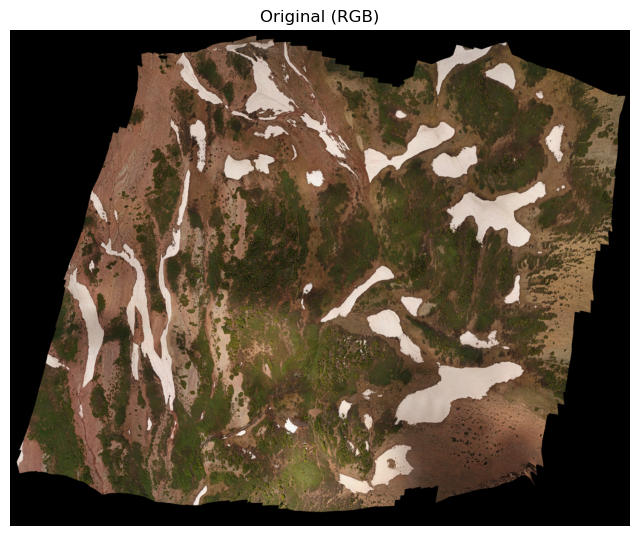

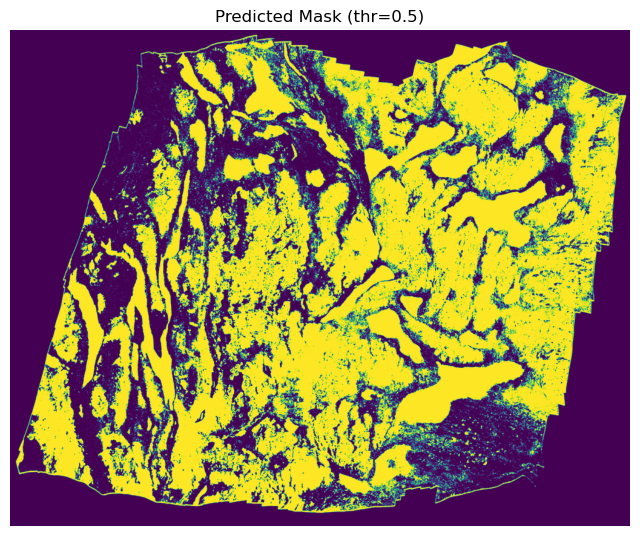

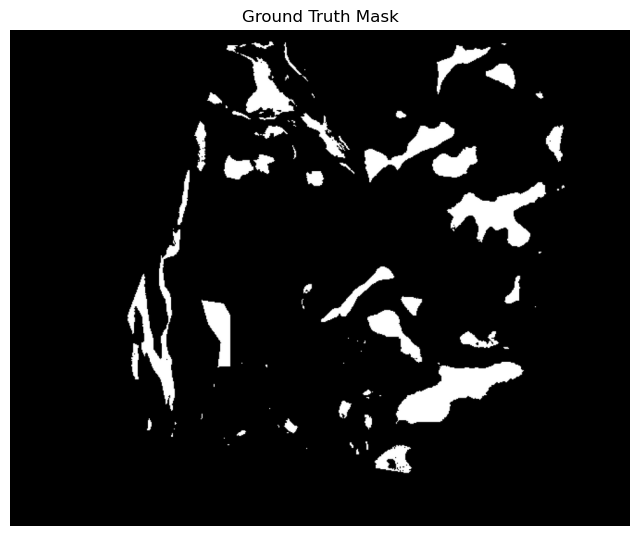

Saving composited TIF overlay => C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\Model_4.5\VirginiaBasin_2020_06_22_overlay.TIFF
Composited TIF saved: C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\Model_4.5\VirginiaBasin_2020_06_22_overlay.TIFF


In [2]:
# -----------------------------
model_path = r"C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_8.4_2025-03-19-01-08\Model_Data\Model_8.4.keras"
large_image_path = r"C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\VirginiaBasin\VirginiaBasin_2020_06_22_snow.tif"
mask_tif_path    = r"C:\Users\jaydb\Snowpack_Project\Upscaled_Masks\Snow_Mask\VirginiaBasin\VirginiaBasin_2020_06_22_snowbinary.tif"
output_overlay   = r"C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\Model_4.5\VirginiaBasin_2020_06_22_overlay.TIFF"
classify_large_image_with_unet(
     model_path, large_image_path, mask_tif_path,
     tile_size=512, overlap=64, threshold=0.5, output_composite=output_overlay, composite_blend=0.5, max_disp_dim=1024
)

Loading model from: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_8.4_2025-03-19-01-08\Model_Data\Model_8.4.keras
Reading large image: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\VirginiaBasin\VirginiaBasin_2020_06_22_snow.tif
Large image shape: (C=4, H=17859, W=22324)
Number of patches: 2000
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Converting patch from shape (4, 512, 512) to 3 channels.
Conver

C:\Users\jaydb\AppData\Local\Temp\ipykernel_13968\1573432524.py:245: RuntimeWarning: overflow encountered in multiply
  mask_disp = resize_for_display((mask_array*255).astype(np.uint8), max_dim=max_disp_dim)
C:\Users\jaydb\AppData\Local\Temp\ipykernel_13968\1573432524.py:245: RuntimeWarning: invalid value encountered in cast
  mask_disp = resize_for_display((mask_array*255).astype(np.uint8), max_dim=max_disp_dim)


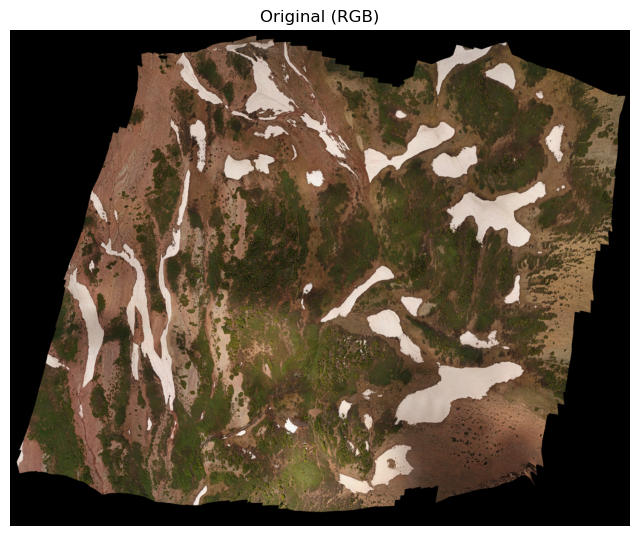

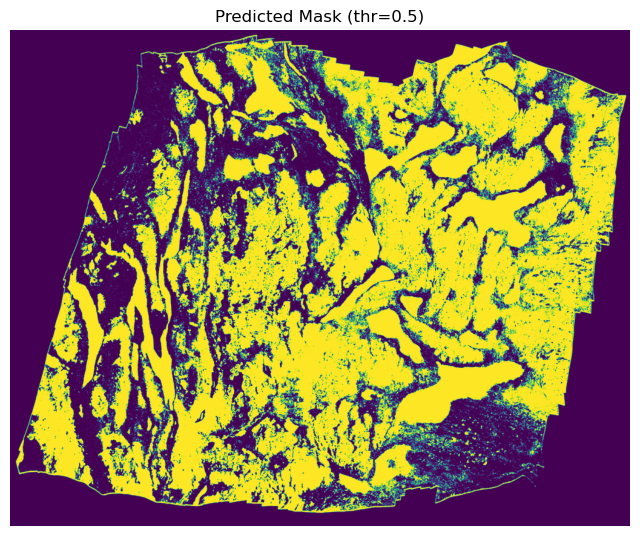

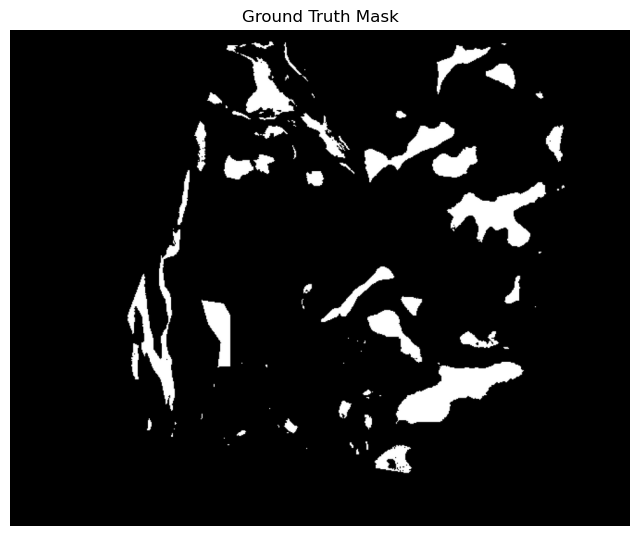

Saving composited TIF overlay => C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\Model_4.5\VirginiaBasin_2020_06_22_overlay.TIFF
Composited TIF saved: C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\Model_4.5\VirginiaBasin_2020_06_22_overlay.TIFF


In [3]:
# -----------------------------
model_path = r"C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_8.4_2025-03-19-01-08\Model_Data\Model_8.4.keras"
large_image_path = r"C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\VirginiaBasin\VirginiaBasin_2020_06_22_snow.tif"
mask_tif_path    = r"C:\Users\jaydb\Snowpack_Project\Upscaled_Masks\Snow_Mask\VirginiaBasin\VirginiaBasin_2020_06_22_snowbinary.tif"
output_overlay   = r"C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\Model_4.5\VirginiaBasin_2020_06_22_overlay.TIFF"
classify_large_image_with_unet(
     model_path, large_image_path, mask_tif_path,
     tile_size=512, overlap=64, threshold=0.5, output_composite=output_overlay, composite_blend=0.5, max_disp_dim=1024
)

Loading model from: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_11.3_2025-04-02-05-33\Model_Data\Model_11.3.keras
Reading large image: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_05_22_snow.tif
Large image shape: (C=3, H=23898, W=28759)
Number of patches: 3510
Reading ground-truth mask: C:\Users\jaydb\Snowpack_Project\Upscaled_Masks\Snow_Mask\DeerCreekTrail\DeerCreekTrail_2019_05_22_snowbinary.tif
Mask shape: (23898, 28759)


C:\Users\jaydb\AppData\Local\Temp\ipykernel_13968\1573432524.py:245: RuntimeWarning: overflow encountered in multiply
  mask_disp = resize_for_display((mask_array*255).astype(np.uint8), max_dim=max_disp_dim)
C:\Users\jaydb\AppData\Local\Temp\ipykernel_13968\1573432524.py:245: RuntimeWarning: invalid value encountered in cast
  mask_disp = resize_for_display((mask_array*255).astype(np.uint8), max_dim=max_disp_dim)


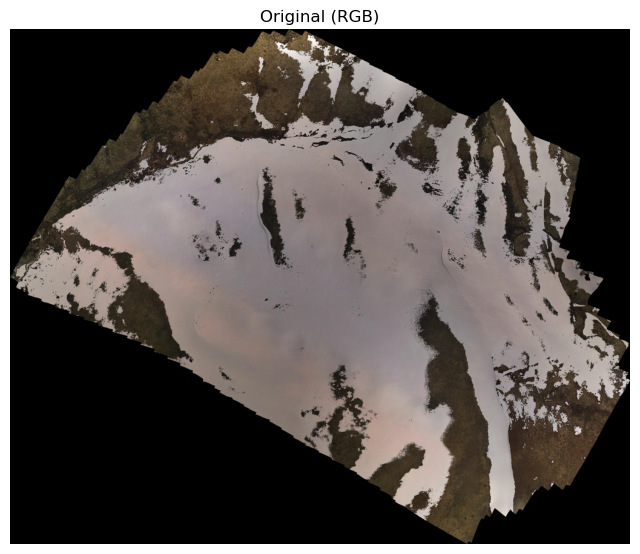

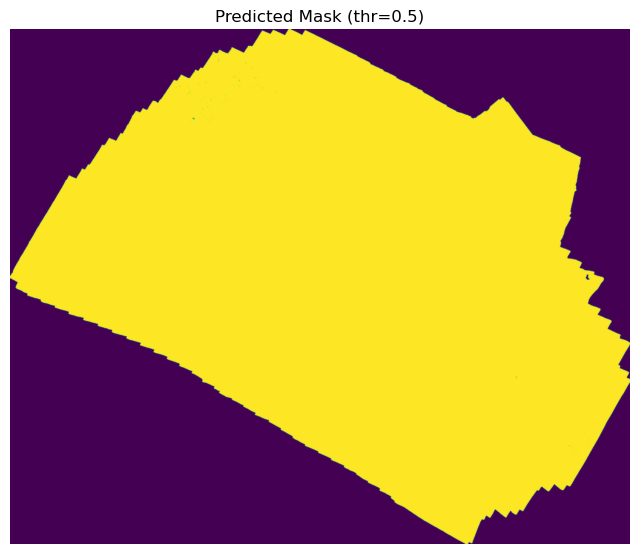

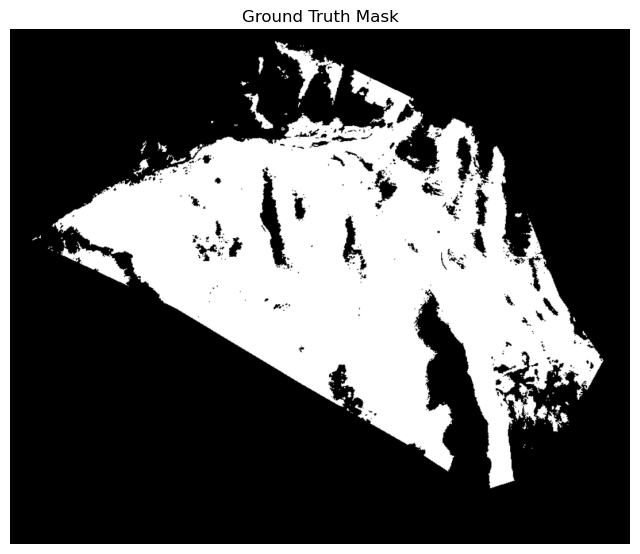

Saving composited TIF overlay => C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\gpu_test_2\DeerCreekTrail_2019_05_22_overlay.TIFF
Composited TIF saved: C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\gpu_test_2\DeerCreekTrail_2019_05_22_overlay.TIFF


In [4]:
model_path = r"C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_11.3_2025-04-02-05-33\Model_Data\Model_11.3.keras"
large_image_path = r"C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_05_22_snow.tif"
mask_tif_path    = r"C:\Users\jaydb\Snowpack_Project\Upscaled_Masks\Snow_Mask\DeerCreekTrail\DeerCreekTrail_2019_05_22_snowbinary.tif"
output_overlay   = r"C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\gpu_test_2\DeerCreekTrail_2019_05_22_overlay.TIFF"
classify_large_image_with_unet(
     model_path, large_image_path, mask_tif_path,
     tile_size=512, overlap=64, threshold=0.5, output_composite=output_overlay, composite_blend=0.5, max_disp_dim=1024
)

Loading model from: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_11.2_2025-04-02-02-45\Model_Data\Model_11.2.keras
Reading large image: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_05_22_snow.tif
Large image shape: (C=3, H=23898, W=28759)
Number of patches: 3510
Reading ground-truth mask: C:\Users\jaydb\Snowpack_Project\Upscaled_Masks\Snow_Mask\DeerCreekTrail\DeerCreekTrail_2019_05_22_snowbinary.tif
Mask shape: (23898, 28759)


C:\Users\jaydb\AppData\Local\Temp\ipykernel_13968\1573432524.py:245: RuntimeWarning: overflow encountered in multiply
  mask_disp = resize_for_display((mask_array*255).astype(np.uint8), max_dim=max_disp_dim)
C:\Users\jaydb\AppData\Local\Temp\ipykernel_13968\1573432524.py:245: RuntimeWarning: invalid value encountered in cast
  mask_disp = resize_for_display((mask_array*255).astype(np.uint8), max_dim=max_disp_dim)


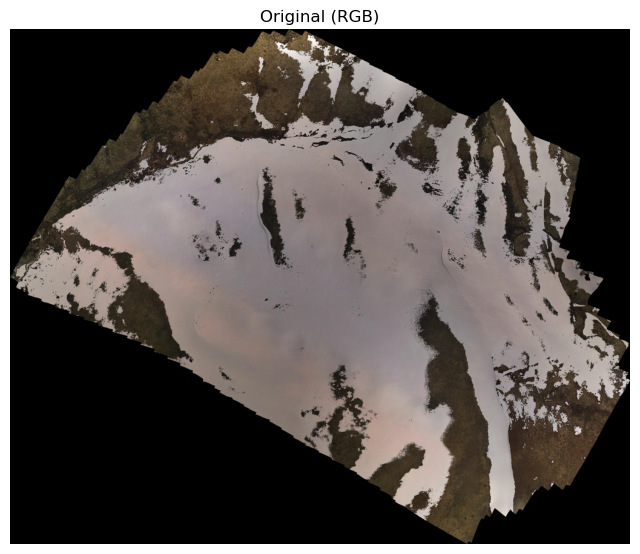

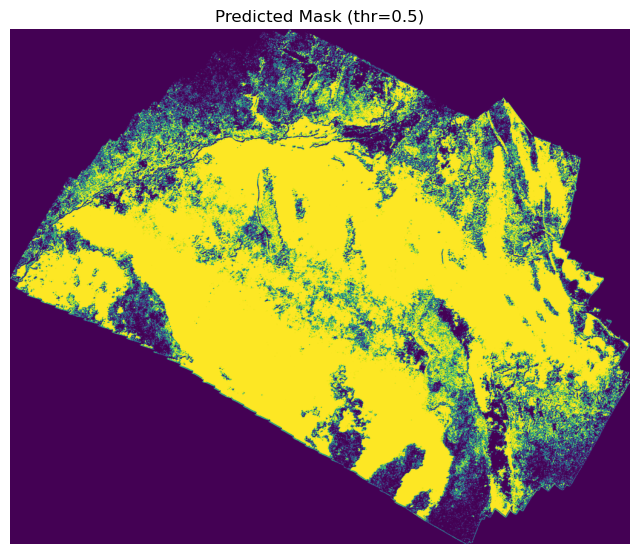

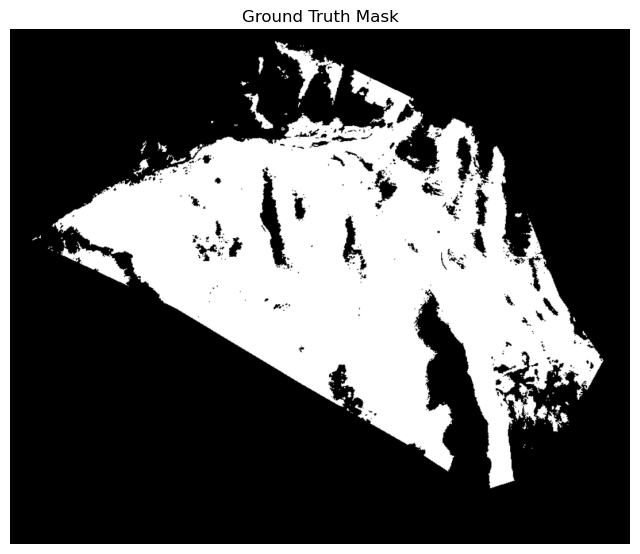

Saving composited TIF overlay => C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\gpu_test_2\DeerCreekTrail_2019_05_22_overlay.TIFF
Composited TIF saved: C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\gpu_test_2\DeerCreekTrail_2019_05_22_overlay.TIFF


In [5]:
# -----------------------------
model_path = r"C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_11.2_2025-04-02-02-45\Model_Data\Model_11.2.keras"
large_image_path = r"C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_05_22_snow.tif"
mask_tif_path    = r"C:\Users\jaydb\Snowpack_Project\Upscaled_Masks\Snow_Mask\DeerCreekTrail\DeerCreekTrail_2019_05_22_snowbinary.tif"
output_overlay   = r"C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\gpu_test_2\DeerCreekTrail_2019_05_22_overlay.TIFF"
classify_large_image_with_unet(
     model_path, large_image_path, mask_tif_path,
     tile_size=512, threshold=0.5, output_composite=output_overlay, composite_blend=0.5
)

Loading model from: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_11.2_2025-04-02-02-45\Model_Data\Model_11.2.keras
Reading large image: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_05_22_snow.tif
Large image shape: (C=3, H=23898, W=28759)
Number of patches: 3510
Reading ground-truth mask: C:\Users\jaydb\Snowpack_Project\Upscaled_Masks\Snow_Mask\DeerCreekTrail\DeerCreekTrail_2019_05_22_snowbinary.tif
Mask shape: (23898, 28759)


C:\Users\jaydb\AppData\Local\Temp\ipykernel_13968\1573432524.py:245: RuntimeWarning: overflow encountered in multiply
  mask_disp = resize_for_display((mask_array*255).astype(np.uint8), max_dim=max_disp_dim)
C:\Users\jaydb\AppData\Local\Temp\ipykernel_13968\1573432524.py:245: RuntimeWarning: invalid value encountered in cast
  mask_disp = resize_for_display((mask_array*255).astype(np.uint8), max_dim=max_disp_dim)


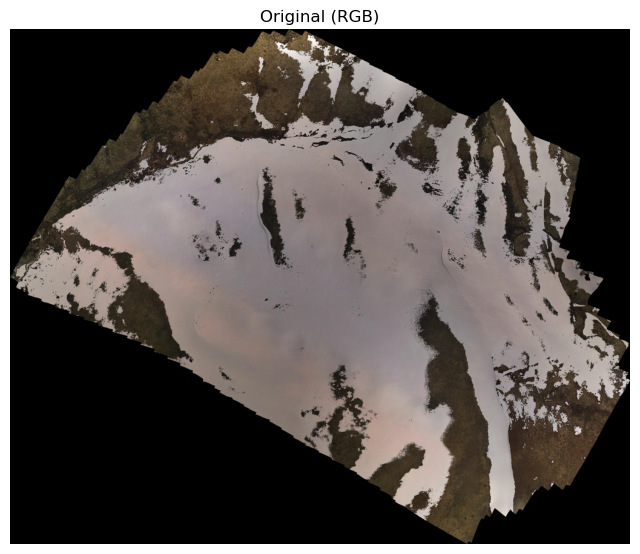

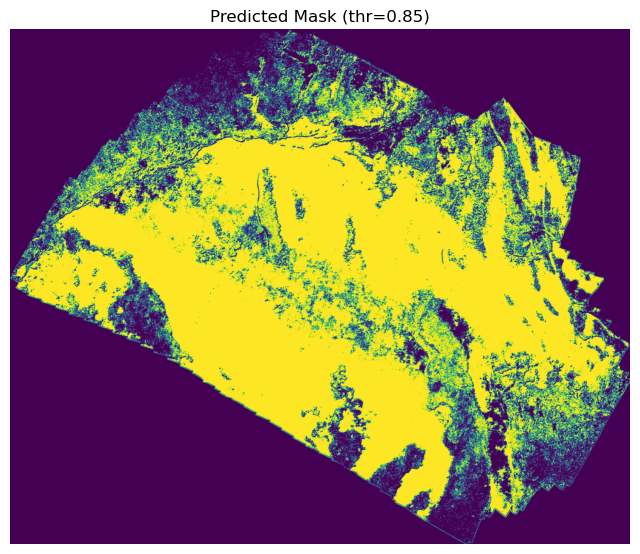

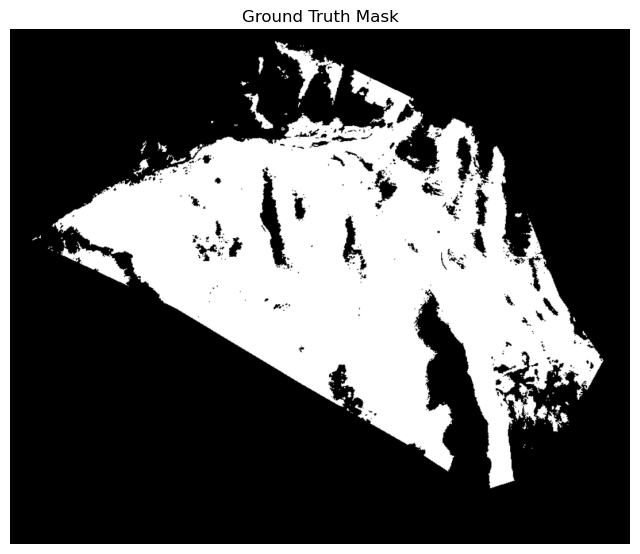

Saving composited TIF overlay => C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\gpu_test_2\DeerCreekTrail_2019_05_22_overlay.TIFF
Composited TIF saved: C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\gpu_test_2\DeerCreekTrail_2019_05_22_overlay.TIFF


In [6]:
# -----------------------------
model_path = r"C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_11.2_2025-04-02-02-45\Model_Data\Model_11.2.keras"
large_image_path = r"C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_05_22_snow.tif"
mask_tif_path    = r"C:\Users\jaydb\Snowpack_Project\Upscaled_Masks\Snow_Mask\DeerCreekTrail\DeerCreekTrail_2019_05_22_snowbinary.tif"
output_overlay   = r"C:\Users\jaydb\Snowpack_Project\Predicted_Masks_Overlay\gpu_test_2\DeerCreekTrail_2019_05_22_overlay.TIFF"
classify_large_image_with_unet(
     model_path, large_image_path, mask_tif_path,
     tile_size=512, threshold=0.85, output_composite=output_overlay, composite_blend=0.5
)